# Validación de inferencia — TextReIDNet (CUHK-PEDES)

Notebook que **carga el modelo entrenado** desde un checkpoint y hace **inferencia text → image**:
dada una descripción textual, rankea las imágenes del *gallery* de test por similitud coseno
entre el embedding del texto y el de cada imagen.

- Modelo: EfficientNet-B0 + BiGRU + DSC (≈ 32.27M params)
- Input imagen: 384×128 (misma normalización que entrenamiento)
- Checkpoint por defecto: `data/checkpoints/TextReIDNet_latest.pth.tar`

> Si no existe un checkpoint, el notebook explica cómo generar uno con `python train.py ...`.


## Cómo usar

1. Ejecuta las celdas en orden (**Run All**).
2. Al final se muestran **N consultas** de texto del split de test, su imagen correcta y el **Top-K**
   de imágenes retornado por el modelo (verde = acierto, rojo = fallo).
3. Puedes cambiar los parámetros del bloque "Parámetros" (gallery, N quieries, Top-K) y re-ejecutar.


In [1]:
# ============ PARÁMETROS (edíta y re-ejecuta) ============
DATASET_SOURCE = 'original'                 # 'original' | 'huggingface'
GALLERY_SIZE = 300                          # nº de imágenes de galería (≤3128); 0 = todas
QUERY_IDXS = [100, 2000, 4000]              # índices de consultas en el test set
TOP_K = 5                                   # cuántos retornar por consulta
SEED = 0
# ========================================================


In [2]:
import os, sys

# Buscar el root del repo (donde está config.py) hacia arriba desde el cwd,
# el notebook puede ejecutarse desde notebooks/ o desde la raíz.
_repo_root = None
_d = os.getcwd()
while os.path.dirname(_d) != _d:
    if os.path.isfile(os.path.join(_d, 'config.py')):
        _repo_root = _d
        break
    _d = os.path.dirname(_d)
if _repo_root is None:
    raise RuntimeError('No se encontró config.py (raíz del repo)')
sys.path.insert(0, _repo_root)

CHECKPOINT = os.path.join(_repo_root, 'data', 'checkpoints', 'TextReIDNet_latest.pth.tar')

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T

from config import sys_configuration
from model.textreidnet import TextReIDNet
from datasets.cuhkpedes import CUHKPEDES
from datasets.bert_tokenizer import BERTTokenizer
from utils.miscellaneous_utils import pad_tokens

%matplotlib inline

config = sys_configuration(dataset_name='CUHK-PEDES', dataset_source=DATASET_SOURCE)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('cwd:', os.getcwd())
print('repo root:', _repo_root)
print('device:', device)


/home/dc-2019/textreid_train/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cwd: /home/dc-2019/textreid_train/notebooks
repo root: /home/dc-2019/textreid_train
device: cuda


In [4]:
if not os.path.isfile(CHECKPOINT):
    raise FileNotFoundError(
        f'No hay checkpoint en {CHECKPOINT}. Entrena primero o actualiza CHECKPOINT:\n'
        f'  .venv/bin/python train.py --dataset_source {DATASET_SOURCE} --epochs 60 --batch_size 128'
    )

# --- Construir modelo y cargar pesos ---
model = TextReIDNet(config).to(device)
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
if 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
    epoch = ckpt.get('epoch')
else:
    model.load_state_dict(ckpt)
    epoch = '?'
model.eval()
print(f'Checkpoint cargado OK — época: {epoch}')
print(f'Parámetros: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M')


Checkpoint cargado OK — época: 60
Parámetros: 32.27M


In [5]:
# --- Cargar split test del dataset ---
ds = CUHKPEDES(config)
test = ds.test
img_paths = test['img_paths']
image_pids = test['image_pids']
captions = test['captions']
caption_pids = test['caption_pids']
print(f'Galería (imágenes): {len(img_paths)} | Consultas (texto): {len(captions)}')

# Transform idéntico al de evaluación/entrenamiento (inf.)
transform = T.Compose([
    T.Resize(tuple(config.CUHKPEDES_image_size), T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=config.mean, std=config.std),
])
tokenizer = BERTTokenizer()

@torch.no_grad()
def img_embedding(path):
    """Embedding L2-normalizado de una imagen."""
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    f = model.image_embedding(x)
    return torch.nn.functional.normalize(f.view(1, -1), dim=1).cpu()

@torch.no_grad()
def txt_embedding(caption):
    """Embedding L2-normalizado de un caption."""
    tokens = tokenizer(caption)
    tok_ids, tok_len = pad_tokens(tokens, config.tokens_length_max)
    tok_ids = tok_ids.long().unsqueeze(0).to(device)
    tok_len = torch.tensor([tok_len]).to(device)
    f = model.text_embedding(tok_ids, tok_len)
    return torch.nn.functional.normalize(f.view(1, -1), dim=1).cpu()


Galería (imágenes): 3128 | Consultas (texto): 6256


In [6]:
# --- Construir galería (submuestra) y precomputar embeddings de imagen ---
N = len(img_paths)
if GALLERY_SIZE == 0 or GALLERY_SIZE >= N:
    gal_idx = np.arange(N)
else:
    rng = np.random.RandomState(SEED)
    gal_idx = rng.choice(N, GALLERY_SIZE, replace=False)
gal_idx = np.sort(gal_idx)
gal_feats = []
for j, i in enumerate(gal_idx):
    gal_feats.append(img_embedding(img_paths[i]))
    if (j + 1) % 100 == 0:
        print(f'  imágenes procesadas: {j + 1}/{len(gal_idx)}')
gal_feats = torch.cat(gal_feats, 0)
gal_pids = [image_pids[int(i)] for i in gal_idx]
print(f'Galería final: {len(gal_idx)} imágenes, embeddings {tuple(gal_feats.shape)}')


  imágenes procesadas: 100/300
  imágenes procesadas: 200/300
  imágenes procesadas: 300/300
Galería final: 300 imágenes, embeddings (300, 1024)


In [7]:
def find_gt_image(pid, gal_idx, img_paths, image_pids):
    """Devuelve el path de una imagen (de la galería si es posible) de la persona `pid`."""
    for j, g in enumerate(gal_idx):
        if image_pids[int(g)] == pid:
            return img_paths[int(g)]
    for i, p in enumerate(image_pids):
        if p == pid:
            return img_paths[i]
    return None

results = []
for qi in QUERY_IDXS:
    if qi >= len(captions):
        print(f'[skip] índice de consulta {qi} fuera de rango ({len(captions)})')
        continue
    pid = caption_pids[qi]
    cap = captions[qi]
    qfeat = txt_embedding(cap)
    sims = (qfeat @ gal_feats.t())[0]
    order = torch.argsort(sims, descending=True)[:TOP_K]
    ranked = [{'idx': int(gal_idx[j]), 'pid': gal_pids[j], 'sim': float(sims[j]),
               'hit': gal_pids[j] == pid} for j in order.tolist()]
    hit_k = sum(r['hit'] for r in ranked)
    results.append({'pid': pid, 'caption': cap, 'ranked': ranked,
                    'gt_path': find_gt_image(pid, gal_idx, img_paths, image_pids),
                    'hit_k': hit_k})
    print(f'consulta #{qi} pid={pid} — aciertos en top-{TOP_K}: {hit_k}/{TOP_K}; sim top1={ranked[0]["sim"]:.3f}')


consulta #100 pid=12020 — aciertos en top-5: 0/5; sim top1=0.624
consulta #2000 pid=12324 — aciertos en top-5: 1/5; sim top1=0.606
consulta #4000 pid=12643 — aciertos en top-5: 0/5; sim top1=0.719



PID objetivo: 12020  —  Aciertos top-5: 0/5
Caption : This tall, thin young man has short black hair and he S wearing glasses, a black shirt, dark Gray shorts and he S carrying a backpack over one shoulder.


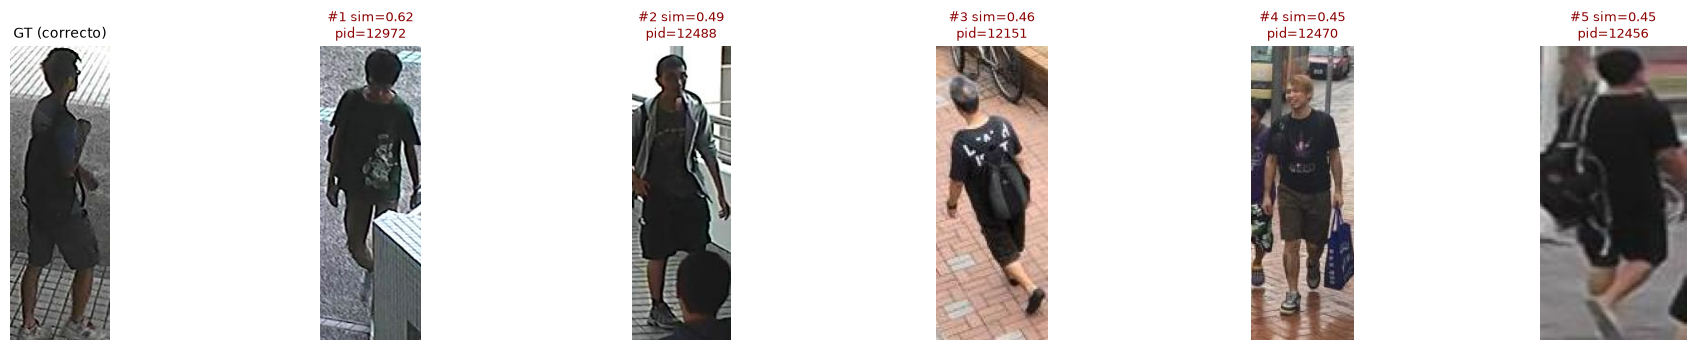


PID objetivo: 12324  —  Aciertos top-5: 1/5
Caption : A man in a pink shirt, a pair of black shorts and a pair of neon green shoes.


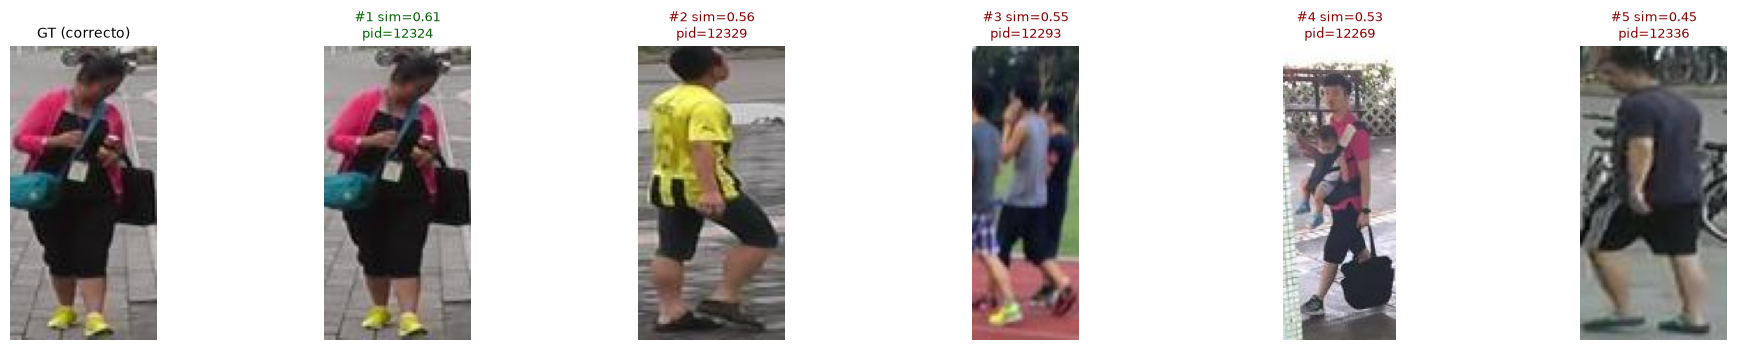


PID objetivo: 12643  —  Aciertos top-5: 0/5
Caption : The woman is wearing her hair in a ponytail. She is also wearing a white shirt and black pants.


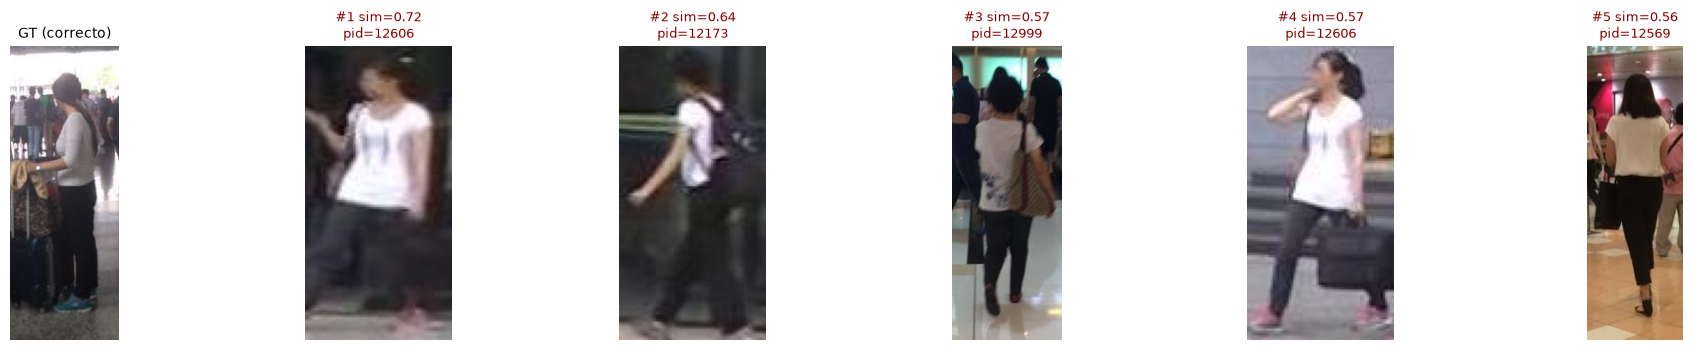

In [8]:
def show_results(results, TOP_K):
    for r in results:
        print('\n' + '=' * 90)
        print(f'PID objetivo: {r["pid"]}  —  Aciertos top-{TOP_K}: {r["hit_k"]}/{TOP_K}')
        print(f'Caption : {r["caption"]}')
        ncols = TOP_K + 1
        fig, axes = plt.subplots(1, ncols, figsize=(3.3 * ncols, 3.6))
        for ax in axes:
            ax.axis('off')
        # columna 0: imagen correcta (ground truth)
        gt = Image.open(r['gt_path']).convert('RGB')
        axes[0].imshow(np.asarray(gt))
        axes[0].set_title('GT (correcto)', fontsize=10)
        # resto: ranking
        for k, it in enumerate(r['ranked']):
            im = Image.open(img_paths[it['idx']]).convert('RGB')
            axes[k + 1].imshow(np.asarray(im))
            color = 'darkgreen' if it['hit'] else 'darkred'
            axes[k + 1].set_title(f'#{k+1} sim={it["sim"]:.2f}\npid={it["pid"]}', fontsize=9, color=color)
        plt.tight_layout()
        plt.show()

show_results(results, TOP_K)


## Lectura de los resultados

- **Grid verde oscuro** = el modelo acertó (el pid retornado coincide con el de la consulta).
- **Grid rojo oscuro** = fallo (pid distinto).
- Cuanto más baja la similitud en el top, más a dudar; con más épocas de entrenamiento
  el top-1 debería acercarse al **52.76%** reportado por el paper.

Para métricas globales (Top-1/Top-5/Top-10/mAP sobre todo el test set) usa:

```bash
.venv/bin/python evaluate.py --checkpoint data/checkpoints/TextReIDNet_latest.pth.tar --dataset_source original --split test
```
